<a href="https://colab.research.google.com/github/Kigunda-lilian/Data_science/blob/main/lec10_notebook_answer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 7 SQL and Database

**Chapter Introduction**

In Chapter 7, we will explore SQL, a programming language to manage large-scale databases. In this notebook, we will use **DuckDB**, a lightweight, serverless database engine renowned for its simplicity and ease of use.

In this chapter, you will learn how to create and manage databases, construct and execute various SQL queries, and manipulate data effectively within the DuckDB environment. Through a series of structured exercises, you will develop the skills necessary to perform essential database operations, such as database creation and data retrieval, updating, deletion, and aggregation.

Goal: Understand the role of database and learn basic skills to use SQL.

- **[7.1 Chapter Overview](#7.1-この章の概要)**
    - [7.1.1 What Is a Database](#7.1.1-データベースとは)
    - [7.1.2 RDBMS](#7.1.2-RDBMS)
<br><br>
- **[7.2 SQL Basics](#7.2-SQLの基礎)**
    - [7.2.1 Creating Databases and Tables](#7.2.1-データベースとテーブルの作成)
    - [7.2.2 Querying, Updating, Deleting, and Modifying Table Columns](#7.2.2-データの検索と更新、削除、テーブルカラムの変更)
    - [7.2.3 Data Aggregation, Calculation, and Sorting](#7.2.3-データの集計、演算、並び替え)
    - [7.2.4 Group-Based Aggregation](#7.2.4-グループごとの集計)
    - [7.2.5 Using Multiple Tables](#7.2.5-複数テーブルの利用)
    - [7.2.6 CASE Statements and Subqueries](#7.2.6-case文とサブクエリ)
<br><br>
- **[7.3 Views](#7.3-ビュー)**
    - [7.3.1 Views](#7.3.1-ビュー)
<br><br>
- **[7.4 Comprehensive Questions](#7.4-総合問題)**
    - [■ Comprehensive Question 7-1](#7.4.1-総合問題1)

## 7.1 Chapter Overview
Keywords: database, RDBMS, table, SQL, MySQL, DuckDB

### 7.1.1 What Is a Database

In this section, we will learn about databases.

A **database** is a collection of data that is managed so it can be utilized for various needs later on by using a computer to consolidate large amounts of information in one place.

#### Why Use Database?

Why do we need databases in the first place? For small datasets that do not require high levels of consistency, Excel might be sufficient. However, data grows by the day, and especially with the rise of IoT, vast amounts of data are now generated in real time. In today's era of **big data**, it is not unusual to see data sources with over 100 million records in a single table, making it extremely difficult to process using Excel alone. By using databases and SQL (the programming language used to manage them), we can efficiently handle large volumes of data. (Today, software like Hadoop and Spark is commonly used for distributed processing of big data.)

Moreover, from a management perspective, Excel has its limitations. By default, anyone can edit an Excel file, and if there is a problem in the data later on, it can be difficult to fix. In Excel, different types of data can be freely entered in columns, and managing them uniformly is challenging. By using a database, data can be managed more easily. Also, to prevent multiple people from editing data simultaneously, databases implement “exclusive control”, which locks the data so others cannot modify it. The figure below illustrates this process.

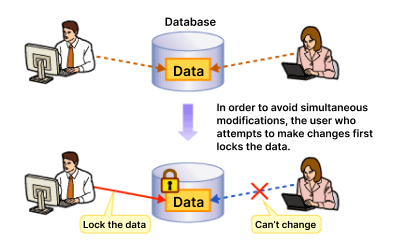

Reference URL：http://image.itmedia.co.jp/ait/articles/1105/30/r501-01.gif

#### Relational Database

In this notebook, we will deal with a type of database called **relational database**. A relational database contains multiple tables, and each table holds different data.

The following figure illustrates the relationship between a database and its tables. Rows in a table are called **records**, and columns are called **columns**, or fields. The tables are connected using **keys**, which are columns that represent a unique identifier of each record and are shared across tables.

![comment](https://hbs-rcs.github.io/sql-novice-survey/fig/RelationalDB.PNG)

Reference URL: https://hbs-rcs.github.io/sql-novice-survey/fig/RelationalDB.PNG

A database contains tables, and data is retrieved from these tables. Each table consists of several columns, which can store different types of data, such as numbers, text, or dates. In Excel, you can mix numbers and text in the same column, but in a database table, each column must specify a single data type. Because the data is organized in this manner, it becomes much easier to perform aggregations later on. We will learn how to work with this data in detail as we proceed.

#### Examples of Relational Database

For instance, a store might manage its daily sales data in a database. Personal customer information, employee salary information, financial transaction data, and website access log data may also be stored in databases. Taking purchase data as an example, you might have entries in a table indicating the date and time a product was sold, the code that identifies the product, the purchaser, the price, and the quantity. These data entries are added on a daily basis, and whenever an aggregation is needed (such as calculating monthly sales), the data is extracted from the database and deleted if no longer necessary.


### 7.1.2 RDBMS


The database system we will study in this chapter is called an **RDBMS**, a Relational Database Management System. Major examples include Oracle, Microsoft SQL Server, PostgreSQL, and MySQL.

The figure below shows a conceptual diagram of a RDBMS.

![comment](https://www.mysql.com/common/images/products/MySQL_Workbench_Visual_Design_Windows.gif)

Reference URL: https://www.mysql.com/common/images/products/MySQL_Workbench_Visual_Design_Windows.gif

In this course, we will use a RDBMS called **DuckDB**.

Note: The following is the documentation of DuckDB, so please consult it as needed.

Reference URL: https://duckdb.org/

For those who have never used SQL before, the references below are particularly accessible for beginners. Some involve PHP or other connections, but they are not required to understand this course. If you are interested, feel free to explore them and try creating a simple web service—this is an excellent way to deepen your understanding of databases.

>[Reference]
>
>“From the Basics: MySQL, Revised Edition (Kiso kara Series)” by Yumeno Nishizawa (SB Creative)

This concludes our brief introduction to databases. There are many other concepts out there, but let’s start with implementation so you can learn how to handle data. You will also learn to use SQL more quickly by actually writing and executing queries.

## 7.2 SQL Basics
Keywords: database creation, table, SHOW DATABASES, USE, SHOW TABLES, CREATE, SELECT, WHERE, IN, LIKE, UPDATE, DELETE, ALTER, COUNT, DISTINCT, ORDER, AVG, SUM, LIMIT, GROUP BY, HAVING, UNION, UNION ALL, INNER JOIN, OUTER JOIN, Self-Join, CASE statement, subquery

### 7.2.0 Configuration to Use SQL in Google Colab

We will download the required modules.

In [ ]:
# Download modules for IPython
!pip install jupysql duckdb-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.8/192.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.9 MB/s eta 0:00:00


We will load data and set up the database.

In [ ]:
%load_ext sql
%sql duckdb://

Connecting to 'duckdb://'

From this point on, if you place

```
%%sql
```

at the beginning of a cell, you will be able to use SQL.

***Note: Double quotes (”) cannot be used. Please use single quotes (’). ***

Additionally, while SQL is not case-sensitive, the following conventions are widely adopted to improve code readability and visibility:
*   Write reserved words (SELECT, FROM, WHERE, JOIN, etc.) in uppercase
*   Write table names and column names in lowercase
*   Use underscores (_) to separate words in multi-word table or column names

### 7.2.1 Creating a Database and a Table

** Note: This includes practice exercises. Please execute them in order as we will use them in subsequent tasks.**

#### Creating a Database

To create a database, we use `CREATE DATABASE`.

```sql
CREATE DATABASE database_name;
```

#### Creating a Table

To create a table, we use `CREATE TABLE`. Contrary to Pandas or Excel, you also need to specify the columns and their data types.

```sql
CREATE TABLE table_name (
    column1 INT -- data type: integer
    column2 VARCHAR(20) -- data type: characters of max length 20
);
```

You can also specify which columns to use as **primary keys**, etc. By setting as `PRIMARY KEY`, it means that this column is a unique key, therefore disallowing duplicates.

```sql
CREATE TABLE table_name (
    column1 INT PRIMARY KEY -- data type: integer, primary key
    column2 VARCHAR(20) -- data type: characters of max length 20
);
```


Let's create a table called `emp_list` with an integer-type column named `id` and a text-type column named `name`. We also specify `id` as the primary key.


In [ ]:
%%sql
CREATE TABLE emp_list (
    id INT PRIMARY KEY,
    name VARCHAR(20)
);

Running query in 'duckdb://'

Count


#### Retrieving Data

To retrieve a data from a table, we use `SELECT`. When using `SELECT`, you can also combine `FROM` to specify the table and `WHERE` to add any conditions. (See 7.2.2 for conditional retrieval)

To select all columns, we use an asterisk (*).

```sql
SELECT * FROM table_name;
```

**Remember to add a semicolon at the end, which represents the end of a row.**

To select certain columns, you would write as follows:

```sql
SELECT column1, column2 FROM table_name;
```

Let's use `SELECT` on the table we created above. Since the table is empty, you will see an empty table with no records.

In [ ]:
%%sql
SELECT * FROM emp_list;

Running query in 'duckdb://'

id,name


#### Inserting Data, Rollback

Let’s insert data into the table we created. To insert data, we use `INSERT INTO`.

To insert data into specific columns of the table, you would write as follows:

```sql
INSERT INTO table_name (column1, column2, ...)
VALUES (value1, value2, ...);
```

You can abbreviate the column names if you are inserting into all the columns.

```sql
INSERT INTO table_name
VALUES (value1, value2, ...);
```

**Remember to use single quotation marks when inserting strings.**

We insert three records with the following statements.

In [ ]:
%%sql
INSERT INTO emp_list (id, name) VALUES (1, 'Yamada'); # Please use single quotation marks.

Running query in 'duckdb://'

Count


In [ ]:
%%sql
INSERT INTO emp_list (id, name) VALUES (2, 'Tanaka');

Running query in 'duckdb://'

Count


In [ ]:
%%sql
INSERT INTO emp_list (id, name) VALUES (3, 'Sato');

Running query in 'duckdb://'

Count


Let’s check the table once more.

In [ ]:
%%sql
SELECT * FROM emp_list;

Running query in 'duckdb://'

id,name
1,Yamada
2,Tanaka
3,Sato


If you try to insert data for an id that already exists, you will get an error, as shown below.

In [ ]:
%%sql
INSERT INTO emp_list (id, name) VALUES (1, 'Yamada');

Running query in 'duckdb://'

RuntimeError: (duckdb.duckdb.ConstraintException) Constraint Error: Duplicate key "id: 1" violates primary key constraint. If this is an unexpected constraint violation please double check with the known index limitations section in our documentation (https://duckdb.org/docs/sql/indexes).
[SQL: INSERT INTO emp_list (id, name) VALUES (1, 'Yamada');]
(Background on this error at: https://sqlalche.me/e/20/gkpj)
If you need help solving this issue, send us a message: https://ploomber.io/community


**ROLLBACK** clears the interrupted transaction state caused by the error in the previous cell.
Without doing this, subsequent code will not run due to errors.

Alternatively, you can disconnect the runtime and re-run everything from the beginning.

In [ ]:
%%sql
ROLLBACK;

Running query in 'duckdb://'

Success


You can check the list of tables with the following SQL statement.

In [ ]:
%%sql
SELECT name FROM sqlite_master WHERE type='table';

Running query in 'duckdb://'

name
emp_list


>**[Key Points]**
>
>CREATE DATABASES [database_name]：Create a database
>
>CREATE TABLE [table_name] [column_name data_type]：Create a table
>
>CREATE TABLE [table_name] [column_name data_type] PRIMARY KEY：Set a primary key
>
>SELECT * FROM table_name: Query all data in the columns of the table
>
>INSERT INTO [table_name] [column_name data_type] [value]：Insert data

#### <Practice Question 7-1>
Create a new table ‘emp_list2.’ After creating it, check to make sure the table has been successfully created. You may choose any column names and data types.

In [ ]:
%%sql
CREATE TABLE emp_list2
  (id INT PRIMARY KEY, name VARCHAR(20))

Running query in 'duckdb://'

Count


In [ ]:
%%sql
SELECT name FROM sqlite_master WHERE type='table';

Running query in 'duckdb://'

name
emp_list
emp_list2


#### <Practice Question 7-2>

Add data to the new table ‘emp_list2’ you created in Practice Question 7-1. After adding the data, verify that the table indeed contains the new records.

In [ ]:
%%sql
INSERT INTO emp_list2 (id, name) VALUES (1, 'Yamada');

Running query in 'duckdb://'

Count


In [ ]:
%%sql
SELECT * FROM emp_list2

Running query in 'duckdb://'

id,name
1,Yamada


### 7.2.2 Searching, Updating, and Deleting Data and Columns

#### Searching Data

Next, let’s try extracting data under certain conditions. We use `SELECT` statement with `WHERE` clause for conditional retrieval.

```sql
SELECT column1, ... FROM table_name WHERE condition;
```

In the example below, we are extracting the record for the person whose `id` is 2.

In [ ]:
%%sql
SELECT * FROM emp_list WHERE id=2;

Running query in 'duckdb://'

id,name
2,Tanaka


There are several useful operators apart from basic conditional operators, such as equal to (`=`), greater than (`>`), or less than(`<`).

By using `IN`, we can extract records that match several possible values.

The example below extracts records where the `id` is either 1 or 2.

In [ ]:
%%sql
SELECT * FROM emp_list WHERE id IN (1,2);

Running query in 'duckdb://'

id,name
1,Yamada
2,Tanaka


By using `LIKE`, we can perform partial (fuzzy) matching. One wildcard is `%`, which represents any number of characters, including zero.

```sql
SELECT column1, ... FROM table_name
WHERE columnN LIKE 'A%'; -- starts with A
```

```sql
SELECT column1, ... FROM table_name
WHERE columnN LIKE '%A%'; -- contains A
```

```sql
SELECT column1, ... FROM table_name
WHERE columnN LIKE '%A'; -- ends with A
```

In this example, we search for any `name` that starts with S.

In [ ]:
%%sql
SELECT * FROM emp_list WHERE name LIKE 'S%';

Running query in 'duckdb://'

id,name
3,Sato


There is also BETWEEN, which extracts data between the specified range. See documentation for more details.

>**[Try It]**
>
>Experiment with changing the conditions above to search the data in various ways. For instance, how would you search for people whose id is not 1, or for people whose name ends with ‘a’?

#### Updating Data

Up to now, we have been extracting existing data, but let’s try modifying the data. To modify a record, we use `UPDATE`. The syntax is as follows:

```sql
UPDATE table_name
SET column1 = value1, column2 = value2, ...
WHERE condition;
```

**Note that if you forget to add the conditions, all the records will be overwritten**.

We will use UPDATE to change the record for the person whose `id` is 3.

In [ ]:
%%sql
UPDATE emp_list
SET name = 'Suzuki'
WHERE id = 3;

Running query in 'duckdb://'

Count


Check whether the update took place.

In [ ]:
%%sql
SELECT * FROM emp_list;

Running query in 'duckdb://'

id,name
1,Yamada
2,Tanaka
3,Suzuki


#### Deleting Data

Next, let’s discuss how to delete data. We’ll prepare sample data (`id`=4) to apply deletion.

In [ ]:
%%sql
INSERT INTO emp_list (id, name) VALUES (4, 'Dummy');

Running query in 'duckdb://'

Count


In [ ]:
%%sql
SELECT * FROM emp_list;

Running query in 'duckdb://'

id,name
1,Yamada
2,Tanaka
3,Suzuki
4,Dummy


Use `DELETE` to remove data. The syntax is as follows:

```sql
DELETE FROM table_name
WHERE condition;
```



Here, we will remove the person whose `id` is 4 that we prepared just now.

In [ ]:
%%sql
DELETE FROM emp_list
WHERE id = 4;

Running query in 'duckdb://'

Count


For caution’s sake, verify that the record is indeed gone.

In [ ]:
%%sql
SELECT * FROM emp_list;

Running query in 'duckdb://'

id,name
1,Yamada
2,Tanaka
3,Suzuki


#### Modify Columns

Next, let’s add new columns.

To modify columns of existing table, we use `ALTER TABLE`. To add columns, we write as follows:

```sql
ALTER TABLE table_name ADD column_name datatype;
```

You can also use `ALTER TABLE` to delete or rename columns as well. See documentation for more details.

We will add the person’s class and age.

In [ ]:
%%sql
ALTER TABLE emp_list ADD class INT;

Running query in 'duckdb://'

Success


In [ ]:
%%sql
ALTER TABLE emp_list ADD age INT;

Running query in 'duckdb://'

Success


Check the table with the newly added columns. The `class` and `age` columns are still empty (NULL) because no data has been entered yet.

In [ ]:
%%sql
SELECT * FROM emp_list;

Running query in 'duckdb://'

id,name,class,age
1,Yamada,None,None
2,Tanaka,None,None
3,Suzuki,None,None


Use UPDATE to update the data.

In [ ]:
%%sql
UPDATE emp_list
SET class=1,age=13
WHERE id=3;

Running query in 'duckdb://'

Count


The record for the person whose `id` is 3 has now been updated with `class` and `age`.

In [ ]:
%%sql
SELECT * FROM emp_list;

Running query in 'duckdb://'

id,name,class,age
1,Yamada,None,None
2,Tanaka,None,None
3,Suzuki,1,13


Let’s continue and update the data for the other people as well.

In [ ]:
%%sql
UPDATE emp_list
SET class=1,age=14
WHERE id=1;

Running query in 'duckdb://'

Count


In [ ]:
%%sql
UPDATE emp_list
SET class=2,age=13
WHERE id=2;

Running query in 'duckdb://'

Count


In [ ]:
%%sql
SELECT * FROM emp_list;

Running query in 'duckdb://'

id,name,class,age
1,Yamada,1,14
2,Tanaka,2,13
3,Suzuki,1,13


Now let’s add data for some new people. Previously, we ran INSERT statements one at a time. Here, we will update multiple records at once with the following command.

In [ ]:
%%sql
INSERT INTO emp_list (id,name,class,age)
VALUES (4,'Kato',2,15),(5,'Ito',3,12),(6,'Takeuchi',2,16),(7,'Kimura',3,11),(8,'Sato',1,14);

Running query in 'duckdb://'

Count


Check the data.

In [ ]:
%%sql
SELECT * FROM emp_list;

Running query in 'duckdb://'

id,name,class,age
1,Yamada,1,14
2,Tanaka,2,13
3,Suzuki,1,13
4,Kato,2,15
5,Ito,3,12
6,Takeuchi,2,16
7,Kimura,3,11
8,Sato,1,14


>**[Key Points]**
>
>SELECT * FROM [table_name] WHERE condition: Narrow down data by condition
>
>IN: Condition match
>
>LIKE: Fuzzy search
>
>DELETE FROM [table_name]: Delete data (note: use WHERE clause to narrow down if needed)
>
>ALTER [table_name] ADD [column_name data_type]: Add a column to the table
>
>UPDATE [table_name] SET : Update data

#### <Practice Question 7-3>
In the ‘emp_list’ table mentioned above, extract the record for the person whose id is 4.

In [ ]:
%%sql
SELECT * FROM emp_list WHERE id = 4;

Running query in 'duckdb://'

id,name,class,age
4,Kato,2,15


#### <Practice Question 7-4>

In the same ‘emp_list’ table, update the class for the person whose id is 8 to 7. After verifying with a SELECT statement that the update was successful, revert the class for the person whose id is 8 back to 1.

In [ ]:
%%sql
SELECT * FROM emp_list WHERE id = 8;

Running query in 'duckdb://'

id,name,class,age
8,Sato,1,14


In [ ]:
%%sql
UPDATE emp_list
SET class = 7
WHERE id=8;

Running query in 'duckdb://'

Count


In [ ]:
%%sql
SELECT * FROM emp_list WHERE id = 8;

Running query in 'duckdb://'

id,name,class,age
8,Sato,7,14


In [ ]:
%%sql
UPDATE emp_list
SET class = 1
WHERE id=8;

Running query in 'duckdb://'

Count


In [ ]:
%%sql
 SELECT * FROM emp_list WHERE id = 8;

Running query in 'duckdb://'

id,name,class,age
8,Sato,1,14


#### <Practice Question 7-5>　(※Mandatory: will be used in subsequent problems)

In the same ‘emp_list’ table, add a new column called ‘height.’ Then update it so that the people whose ids range from 1 to 4 have a height of 150, those whose ids are 5 to 6 have a height of 155, and those whose ids are 7 to 8 have a height of 160.

In [ ]:
%%sql
ALTER TABLE emp_list ADD height INT;

Running query in 'duckdb://'

Success


In [ ]:
%%sql
UPDATE emp_list
SET height=150
WHERE id<=4;

Running query in 'duckdb://'

Count


In [ ]:
%%sql
UPDATE emp_list
SET height=155
WHERE id>=5 AND id<=6;

Running query in 'duckdb://'

Count


In [ ]:
%%sql
UPDATE emp_list
SET height=160
WHERE id>=7;

Running query in 'duckdb://'

Count


In [ ]:
%%sql
SELECT * FROM emp_list;

Running query in 'duckdb://'

id,name,class,age,height
1,Yamada,1,14,150
2,Tanaka,2,13,150
3,Suzuki,1,13,150
4,Kato,2,15,150
5,Ito,3,12,155
6,Takeuchi,2,16,155
7,Kimura,3,11,160
8,Sato,1,14,160


### 7.2.3 Data Aggregation, Arithmetic, and Sorting

Next, we will look at aggregation using SQL.

#### Counting Data
One of the first things we often want to know when looking at data is the number of records.

In SQL, we use `COUNT()` function to count the number of records.

```sql
SELECT COUNT(*) FROM table_name;
```

Below, we use `COUNT` to determine how many rows there are in `emp_list`.

In [ ]:
%%sql
SELECT COUNT(*) FROM emp_list;

Running query in 'duckdb://'

count_star()
8


You can assign names using `AS`. This is called an alias. Let’s name the column `cnt`.

In [ ]:
%%sql
SELECT COUNT(*) AS cnt FROM emp_list;

Running query in 'duckdb://'

cnt
8


Next, let’s use `COUNT` to count the different types of data. Specifically, we previously saw that there are 8 records, but how many different classes are there? By combining `COUNT` and `DISTINCT`, we can count the number of unique items.

In [ ]:
%%sql
SELECT COUNT(DISTINCT class) AS classCnt FROM emp_list;

Running query in 'duckdb://'

classCnt
3


#### Calculating Using Data

Next, let’s calculate the average. We use `AVG()` function to calculate it.

The following example calculates the average age.

In [ ]:
%%sql
 SELECT AVG(age) AS avgAge FROM emp_list;

Running query in 'duckdb://'

avgAge
13.5


Using the `SUM()` function would give us the total value of a column.

Here, let's confirm that the average age we calculated above matches with taking the sum and dividing by the total number of records.

In [ ]:
%%sql
SELECT CAST(SUM(age) AS REAL) / CAST(COUNT(*) AS REAL) AS avgAge FROM emp_list;

Running query in 'duckdb://'

avgAge
13.5


You will find that it matches the previous result. As you can see, arithmetic operations can be done in the SELECT statement itself.

We can also find the maximum and minimum ages as follows. We see that the youngest is 11 years old and the oldest is 16.

In [ ]:
%%sql
SELECT MIN(age) AS minAge, MAX(age) AS maxAge FROM emp_list;

Running query in 'duckdb://'

minAge,maxAge
11,16


#### Sorting Data

To sort a table, we use `ORDER BY`.

```sql
SELECT column1, ... FROM table_name
ORDER BY columnN; -- default is in ascending order
```

To sort in descending order, we add `DESC` argument at the end.

```sql
SELECT column1, ... FROM table_name
ORDER BY columnN DESC; -- in descending order
```

Note that for strings, `ORDER BY` will sort in alphabetical order.

Let’s sort in descending order based on the `id`.

In [ ]:
%%sql
SELECT * FROM emp_list ORDER BY id DESC;

Running query in 'duckdb://'

id,name,class,age,height
8,Sato,1,14,160
7,Kimura,3,11,160
6,Takeuchi,2,16,155
5,Ito,3,12,155
4,Kato,2,15,150
3,Suzuki,1,13,150
2,Tanaka,2,13,150
1,Yamada,1,14,150


Now, let’s sort by `age` in ascending order (from smallest to largest). The default is ascending.

In [ ]:
%%sql
SELECT * FROM emp_list ORDER BY age;

Running query in 'duckdb://'

id,name,class,age,height
7,Kimura,3,11,160
5,Ito,3,12,155
2,Tanaka,2,13,150
3,Suzuki,1,13,150
1,Yamada,1,14,150
8,Sato,1,14,160
4,Kato,2,15,150
6,Takeuchi,2,16,155


Then, let’s try sorting by two columns: `class` and `age`. The column listed first has priority (in this case, `class`).

In [ ]:
%%sql
SELECT * FROM emp_list ORDER BY class, age;

Running query in 'duckdb://'

id,name,class,age,height
3,Suzuki,1,13,150
1,Yamada,1,14,150
8,Sato,1,14,160
2,Tanaka,2,13,150
4,Kato,2,15,150
6,Takeuchi,2,16,155
7,Kimura,3,11,160
5,Ito,3,12,155


#### Side Note 1: Limiting Number of Rows to Return

Using `LIMIT` allows you to limit the number of rows returned. When working with large volumes of data, you can limit the display count by using `LIMIT`.


In [ ]:
%%sql
SELECT * FROM emp_list LIMIT 3;

Running query in 'duckdb://'

id,name,class,age,height
1,Yamada,1,14,150
2,Tanaka,2,13,150
3,Suzuki,1,13,150


#### Side Note 2: Searching Data with Multiple Conditions

Next, let’s narrow down records with multiple conditions. Use AND to specify simultaneous conditions.

In [ ]:
%%sql
SELECT * FROM emp_list WHERE class=2 AND age>=15;

Running query in 'duckdb://'

id,name,class,age,height
4,Kato,2,15,150
6,Takeuchi,2,16,155


Next, we use OR. This is used when a record meets at least one of the specified conditions.

In [ ]:
%%sql
SELECT * FROM emp_list WHERE class=1 OR age>=15;

Running query in 'duckdb://'

id,name,class,age,height
1,Yamada,1,14,150
3,Suzuki,1,13,150
8,Sato,1,14,160
4,Kato,2,15,150
6,Takeuchi,2,16,155


>**[Key Points]**
>
>COUNT: Count the number of records
>
>AS: Alias (naming)
>
>DISTINCT: Eliminate duplicates
>
>AVG: Average value
>
>MAX: Maximum value
>
>MIN: Minimum value
>
>ORDER BY column_name: Sort in ascending order (use DESC after the column name for descending)


#### <Practice Question 7-6>
In the same ‘emp_list’ table mentioned above, how many different ages are there?

In [ ]:
%%sql
SELECT COUNT(DISTINCT age) AS ageCnt FROM emp_list;

Running query in 'duckdb://'

ageCnt
6


#### <Practice Question 7-7>
Find the height of the tallest and shortest persons.

In [ ]:
%%sql
SELECT MIN(height) AS minHeight, MAX(height) AS maxHeight FROM emp_list;

Running query in 'duckdb://'

minHeight,maxHeight
150,160


#### <Practice Question 7-8>
Extract the records for those whose height is 155 or more and whose class is 3.


In [ ]:
%%sql
SELECT * FROM emp_list WHERE height>=155 AND class=3;

Running query in 'duckdb://'

id,name,class,age,height
5,Ito,3,12,155
7,Kimura,3,11,160


### 7.2.4 Aggregating by Group

Now let’s use SQL to aggregate data by group. This is similar to the pivot table feature in Excel. In SQL, we use `GROUP BY` statement. The syntax is as follows:

```sql
SELECT column1, ...
FROM table_name
GROUP BY column_name(s)
```

`GROUP BY` is often used with aggregation functions such as `COUNT()`, `AVG()`, `MAX()`, `MIN()`, etc.

Here, we will use the `class` as the grouping axis. The following command counts how many people are in each `class`.

In [ ]:
%%sql
SELECT class, COUNT(*) AS num FROM emp_list GROUP BY class;

Running query in 'duckdb://'

class,num
1,3
2,3
3,2


It is also possible to calculate averages for each group. Similarly, you can find minimums and maximums.

In [ ]:
%%sql
SELECT class, COUNT(*) AS num, AVG(age) AS avgAge FROM emp_list GROUP BY class;

Running query in 'duckdb://'

class,num,avgAge
1,3,13.666666666666666
2,3,14.666666666666666
3,2,11.5


We can also filter by conditions.

To filter **after** grouping, you use `HAVING`.

In [ ]:
%%sql
SELECT class, AVG(age) AS avgAge FROM emp_list GROUP BY class HAVING avgAge>13;

Running query in 'duckdb://'

class,avgAge
1,13.666666666666666
2,14.666666666666666


To filter **before** grouping, you use `WHERE`.

In [ ]:
%%sql
SELECT class, AVG(age) AS avgAge FROM emp_list WHERE age > 13 GROUP BY class;

Running query in 'duckdb://'

class,avgAge
1,14.0
2,15.5


See the difference in where `HAVING` or `WHERE` is inserted.

Now let’s use two axes for aggregation. We will count records by `class` × `age`.

In [ ]:
%%sql
SELECT class, age, COUNT(*) AS num FROM emp_list GROUP BY class, age;

Running query in 'duckdb://'

class,age,num
1,13,1
1,14,2
2,13,1
2,15,1
2,16,1
3,11,1
3,12,1


You can also specify which columns to `GROUP BY` by specifing their column numbers. Note that this may be confusing, especially when dealing with larger databases. For anything beyond a simple summary, specifying column names is recommended.


In [ ]:
%%sql
SELECT class, age, COUNT(*) AS num FROM emp_list GROUP BY 1, 2;

Running query in 'duckdb://'

class,age,num
1,13,1
1,14,2
2,13,1
2,15,1
2,16,1
3,11,1
3,12,1


>**[Key Points]**
>
>GROUP BY：Set an axis
>
>HAVING：Set a condition (after grouping)

#### <Practice Question 7-9>

In the ‘emp_list’ table, find the average height for each class.

In [ ]:
#Answers
%%sql
SELECT class, AVG(height) AS avgHeight FROM emp_list GROUP BY class;

Running query in 'duckdb://'

class,avgHeight
1,153.33333333333334
2,151.66666666666666
3,157.5


#### <Practice Question 7-10>

In addition, for each class, find the number of people, the shortest person’s height, and the tallest person’s height.

In [ ]:
#Answers
%%sql
SELECT class, COUNT(*) AS cnt, MIN(height) AS minHeight, MAX(height) AS maxHeight FROM emp_list GROUP BY class;

Running query in 'duckdb://'

class,cnt,minHeight,maxHeight
1,3,150,160
2,3,150,155
3,2,155,160


#### <Practice Question 7-11>

Now filter for people older than 13 and calculate the same items listed above.

In [ ]:
#Answers
%%sql
SELECT class, COUNT(*) AS cnt, MIN(height) AS minHeight, MAX(height) AS maxHeight FROM emp_list WHERE age > 13 GROUP BY class;

Running query in 'duckdb://'

class,cnt,minHeight,maxHeight
1,2,150,160
2,2,150,155


### 7.2.5 Using Multiple Tables

Next, let’s operate on data by using multiple tables. To prepare, we will create a table. Although we could create one using the same method we learned previously, it can be a bit tedious, so we will “copy” an existing table. Below, we use CREATE to name the new table and copy the entire table structure.

We will not use the table created in the previous practice questions, so we will delete it.

In [ ]:
%%sql
DROP TABLE IF EXISTS emp_list2;

Running query in 'duckdb://'

Success


To copy an existing table, we combine `COMBINE TABLE` with `AS`.

```sql
CREATE TABLE new_table_name AS
    SELECT column1, ...
    FROM table_name
    WHERE condition;
```

The records will also be copied from the existing table. To delete all records, we can use a condition that does not match with any record in the existing table.

For example, `class`=100000 does not exist, so there will be zero records.

In [ ]:
%%sql
CREATE TABLE emp_list2 AS SELECT * FROM emp_list WHERE class=10000;

Running query in 'duckdb://'

Count


Check it.

In [ ]:
# Check the data
%%sql
SELECT * FROM emp_list2;

Running query in 'duckdb://'

id,name,class,age,height


Next, we will add data to the new table. Note that the first record is intentionally the same as an existing record in the `emp_list` table (Yamada).

In [ ]:
%%sql
INSERT INTO emp_list2 (id, name, class, age, height)
VALUES (1,'Yamada',1,14,150),
       (9,'Nagata',4,11,160),
       (10,'Sugino',2,13,150),
       (11,'Takayama',1,14,155),
       (12,'John',3,16,165);

Running query in 'duckdb://'

Count


In [ ]:
%%sql
 SELECT * FROM  emp_list2;

Running query in 'duckdb://'

id,name,class,age,height
1,Yamada,1,14,150
9,Nagata,4,11,160
10,Sugino,2,13,150
11,Takayama,1,14,155
12,John,3,16,165


Now, let’s combine the data.

#### UNION Operator

To concatenate multiple results of `SELECT` statements, we can use `UNION`.

```sql
SELECT column_name(s) FROM table1
UNION -- excludes duplicates
SELECT column_name(s) FROM table2
```

```sql
SELECT column_name(s) FROM table1
UNION ALL -- allows duplicates
SELECT column_name(s) FROM table2
```

As noted above, `UNION` excludes duplicate records, whereas `UNION ALL` allows duplicates.

In [ ]:
%%sql
SELECT * FROM emp_list
UNION
SELECT * FROM emp_list2;

Running query in 'duckdb://'

id,name,class,age,height
5,Ito,3,12,155
6,Takeuchi,2,16,155
1,Yamada,1,14,150
9,Nagata,4,11,160
10,Sugino,2,13,150
11,Takayama,1,14,155
12,John,3,16,165
2,Tanaka,2,13,150
3,Suzuki,1,13,150
4,Kato,2,15,150


If we use `UNION ALL`, you will see two records for `id`=1.

In [ ]:
%%sql
SELECT * FROM emp_list
UNION ALL
SELECT * FROM emp_list2;

Running query in 'duckdb://'

id,name,class,age,height
1,Yamada,1,14,150
2,Tanaka,2,13,150
3,Suzuki,1,13,150
4,Kato,2,15,150
5,Ito,3,12,155
6,Takeuchi,2,16,155
7,Kimura,3,11,160
8,Sato,1,14,160
1,Yamada,1,14,150
9,Nagata,4,11,160


#### JOIN Operator

Next, let’s create a test score table and join it with the ‘emp_list’ table.

In [ ]:
%%sql
CREATE TABLE score
  (id INT PRIMARY KEY, math INT, english INT, science INT);

Running query in 'duckdb://'

Count


Insert sample data into the ‘score’ table.

In [ ]:
%%sql
INSERT INTO score (id, math, english, science)
VALUES (1,10,10,40),(2,NULL,60,100),(3,30,40,60),
       (5,25,31,10),(6,50,30,10),(8,90,100,90),
       (9,67,71,50),(11,100,40,88),(15,76,21,13);

Running query in 'duckdb://'

Count


Check to make sure the data is there.

In [ ]:
%%sql
SELECT * FROM score;

Running query in 'duckdb://'

id,math,english,science
1,10,10,40
2,None,60,100
3,30,40,60
5,25,31,10
6,50,30,10
8,90,100,90
9,67,71,50
11,100,40,88
15,76,21,13


In SQL, we use the `JOIN` operator to join multiple tables. There are four types of JOINs, **(INNER) JOIN**, **LEFT (OUTER) JOIN**, **RIGHT (OUTER) JOIN**, and **FULL (OUTER) JOIN**.

![comment](https://qph.cf2.quoracdn.net/main-qimg-5c60963f6a76a72df5e260baea1293a4)

Reference: https://www.quora.com/Why-are-SQL-joins-so-tough

The syntax of joining is as follows:

```sql
SELECT column_name(s)
FROM table1
JOIN table2 -- join type you want to use
ON table1.column_name = table2.column_name;
```

You can also assign simple aliases to the table names.

```sql
SELECT column_name(s)
FROM table1 t1 -- assign table1 as t1
JOIN table2 t2 -- assign table2 as t2
ON t1.column_name = t2.column_name; -- using aliases
```

Below is an example of an inner join on the `id` column. We assign simple aliases to the table names (a for `emp_list` and b for `score`).

In [ ]:
%%sql
SELECT * FROM emp_list a JOIN score b ON a.id=b.id;

Running query in 'duckdb://'

id,name,class,age,height,id_1,math,english,science
1,Yamada,1,14,150,1,10,10,40
2,Tanaka,2,13,150,2,None,60,100
3,Suzuki,1,13,150,3,30,40,60
5,Ito,3,12,155,5,25,31,10
6,Takeuchi,2,16,155,6,50,30,10
8,Sato,1,14,160,8,90,100,90


Now, let’s do a left outer join using the `id` column. The table on the left is the base, and if no matching data exists on the right, it becomes None (NULL).

In [ ]:
%%sql
SELECT * FROM emp_list a LEFT JOIN score b ON a.id=b.id;

Running query in 'duckdb://'

id,name,class,age,height,id_1,math,english,science
1,Yamada,1,14,150,1,10,10,40
2,Tanaka,2,13,150,2,None,60,100
3,Suzuki,1,13,150,3,30,40,60
5,Ito,3,12,155,5,25,31,10
6,Takeuchi,2,16,155,6,50,30,10
8,Sato,1,14,160,8,90,100,90
4,Kato,2,15,150,None,None,None,None
7,Kimura,3,11,160,None,None,None,None


For reference, it is also possible to join a table to itself in what is called a self-join.

In [ ]:
%%sql
SELECT * FROM emp_list a JOIN emp_list b ON a.id=b.id;

Running query in 'duckdb://'

id,name,class,age,height,id_1,name_1,class_1,age_1,height_1
1,Yamada,1,14,150,1,Yamada,1,14,150
2,Tanaka,2,13,150,2,Tanaka,2,13,150
3,Suzuki,1,13,150,3,Suzuki,1,13,150
4,Kato,2,15,150,4,Kato,2,15,150
5,Ito,3,12,155,5,Ito,3,12,155
6,Takeuchi,2,16,155,6,Takeuchi,2,16,155
7,Kimura,3,11,160,7,Kimura,3,11,160
8,Sato,1,14,160,8,Sato,1,14,160


>**[Key Points]**
>
>UNION: Concatenate multiple `SELECT` results
>
>UNION ALL: Concatenate multiple `SELECT` results with duplicates
>
>INNER JOIN: Inner join
>
>LEFT OUTER JOIN: (Left) Outer join

#### <Practice Question 7-12>

Create a new table called ‘cardtb.’ Include the columns id, point, and money (all INT). Then insert the following data:
<br>(id, point, money) = (1, 100, 1000), (3, 50, 500), (4, 30, 600), (5, 10, 10), (7, 100, 1000), (8, 2000, 100)


In [ ]:
#Answers
%%sql
CREATE TABLE cardtb
  (id INT PRIMARY KEY, point INT, money INT);

Running query in 'duckdb://'

Count


In [ ]:
#Answers
%%sql
INSERT INTO cardtb (id, point, money)
VALUES (1,100,1000),(3,50,500),(4,30,600),(5,10,10),(7,100,1000),(8,2000,100);

Running query in 'duckdb://'

Count


In [ ]:
#Answers
%%sql
SELECT * FROM cardtb;

Running query in 'duckdb://'

id,point,money
1,100,1000
3,50,500
4,30,600
5,10,10
7,100,1000
8,2000,100


#### <Practice Question 7-13>

Perform an inner join with the ‘emp_list’ table using id as the key.


In [ ]:
#Answers
%%sql
SELECT * FROM emp_list a JOIN cardtb b ON a.id=b.id;

Running query in 'duckdb://'

id,name,class,age,height,id_1,point,money
1,Yamada,1,14,150,1,100,1000
3,Suzuki,1,13,150,3,50,500
4,Kato,2,15,150,4,30,600
5,Ito,3,12,155,5,10,10
7,Kimura,3,11,160,7,100,1000
8,Sato,1,14,160,8,2000,100


#### <Practice Question 7-14>
Perform an outer join with the ‘emp_list’ table using id as the key.

In [ ]:
#Answers
%%sql
SELECT * FROM emp_list a LEFT JOIN cardtb b ON a.id=b.id;

Running query in 'duckdb://'

id,name,class,age,height,id_1,point,money
1,Yamada,1,14,150,1,100,1000
3,Suzuki,1,13,150,3,50,500
4,Kato,2,15,150,4,30,600
5,Ito,3,12,155,5,10,10
7,Kimura,3,11,160,7,100,1000
8,Sato,1,14,160,8,2000,100
2,Tanaka,2,13,150,None,None,None
6,Takeuchi,2,16,155,None,None,None


### 7.2.6 CASE Statements and Subqueries

#### CASE Expression

When working with data, there are times when you might want to split it into categories and aggregate each one. SQL allows for conditional logic using `CASE` expression. The syntax is as follows:

```sql
CASE
    WHEN condition1 THEN result1
    WHEN condition2 THEN result2
    ...
    ELSE result
END;
```

In the following example, each class number is assigned a class name (className=A,B,C for class 1,2,3, respectively). The id, name, and class name are returned.

In [ ]:
%%sql
SELECT id, name,
CASE
    WHEN class = 1 THEN 'A'
    WHEN class = 2 THEN 'B'
    WHEN class = 3 THEN 'C'
    ELSE 'others'
END AS className
FROM emp_list;

Running query in 'duckdb://'

id,name,className
1,Yamada,A
2,Tanaka,B
3,Suzuki,A
4,Kato,B
5,Ito,C
6,Takeuchi,B
7,Kimura,C
8,Sato,A


#### Subquery

Subquery is a query inside a query, in a nested structure. Subqueries allow you to treat information extracted from the original table as a separate table.

In this example, we treat the contents of the `emp_list` table as a table named `b` using a subquery.

In [ ]:
%%sql
SELECT b.name, b.age FROM
  (SELECT a.age, a.name FROM emp_list a WHERE a.class = 1) b;

Running query in 'duckdb://'

name,age
Yamada,14
Suzuki,13
Sato,14


Note that in the above example, we specified column names, but if you want to select every column, you can write dot-asterisk (.*) after the alias name.

In [ ]:
%%sql
SELECT b.* FROM
  (SELECT a.* FROM emp_list a WHERE a.class = 1) b;

Running query in 'duckdb://'

id,name,class,age,height
1,Yamada,1,14,150
3,Suzuki,1,13,150
8,Sato,1,14,160


With this, we have finished covering the basic operations of SQL. After the practice questions, we will learn about views.

>**[Key Points]**
>
>CASE WHEN condition THEN A ELSE B END AS new_column_name: Conditional branching

#### <Practice Question 7-15>

In the ‘emp_list’ table, name any record whose height is below 155 as ‘below_155,’ exactly 155 as ‘equal_155,’ and above 155 as ‘over_155.’ Display the table.

In [ ]:
#Answers
%%sql
SELECT id ,name,
CASE
    WHEN height <155 THEN 'below_155'
    WHEN height = 155 THEN 'equal_155'
    WHEN height > 155 THEN 'over_155'
    ELSE 'others'
END AS heightLevel
FROM emp_list;

Running query in 'duckdb://'

id,name,heightLevel
1,Yamada,below_155
2,Tanaka,below_155
3,Suzuki,below_155
4,Kato,below_155
5,Ito,equal_155
6,Takeuchi,equal_155
7,Kimura,over_155
8,Sato,over_155


#### <Practice Question 7-16>
Using the above table and the subquery concept, find out how many people belong to each of those heightLevel categories (the column added in Practice Question 1).

In [ ]:
#Answer
%%sql
SELECT b.heightLevel, COUNT(*) AS cnt
FROM (
    SELECT id, name,
    CASE
        WHEN height <155 THEN 'below_155'
        WHEN height = 155 THEN 'equal_155'
        WHEN height > 155 THEN 'over_155'
        ELSE 'others'
    END AS heightLevel
    FROM emp_list
) b
GROUP BY heightLevel;

Running query in 'duckdb://'

heightLevel,cnt
below_155,4
equal_155,2
over_155,2


#### <Practice Question 7-17>
Using the above table and the subquery concept, find the average age for each of those heightLevel categories (the column added in Practice Question 1).

In [ ]:
#Answers
%%sql
SELECT b.heightLevel, AVG(age) AS avgAge
FROM (
    SELECT
    id, name, age,
    CASE
        WHEN height <155 THEN 'below_155'
        WHEN height = 155 THEN 'equal_155'
        WHEN height > 155 THEN 'over_155'
        ELSE 'others'
    END AS heightLevel
    FROM emp_list
) b
GROUP BY heightLevel;

Running query in 'duckdb://'

heightLevel,avgAge
below_155,13.75
equal_155,14.0
over_155,12.5


## 7.3 View
Keywords: View

### 7.3.1 View


Next, let’s learn about views.

A **view** is a virtual table that stores your query logic in advance.
So far, we have been querying data directly from tables to obtain the information we need. However, setting conditions and extracting data from each table every single time can be a bit tedious. We could create a table for every type of data we need, but this requires updating the table every time the source data changes. Using views allows us to always obtain the latest data easily without updating the table.

The method for creating a view is almost the same as for creating a table, except we use `CREATE VIEW`.

```sql
CREATE VIEW view_name AS
SELECT columns1, ...
FROM table_name;
```

Let’s start with a simple example. Below, we create a view that retrieves only the `id` and `name` from the `emp_list` table.

In [ ]:
%%sql
CREATE VIEW v1 AS
SELECT id, name
FROM emp_list;

Running query in 'duckdb://'

Count


Check whether the new view has been created. You can do this the same way you learned before.

In [ ]:
%%sql
SELECT * FROM v1;

Running query in 'duckdb://'

id,name
1,Yamada
2,Tanaka
3,Suzuki
4,Kato
5,Ito
6,Takeuchi
7,Kimura
8,Sato


So far, this does not really demonstrate the convenience of views, so let’s look at another example. By creating a view for a specific query, you would be able to access the results without having to write the query again.

In [ ]:
%%sql
CREATE VIEW v2 AS
SELECT id, name,
CASE
    WHEN class = 1 THEN 'A'
    WHEN class = 2 THEN 'B'
    WHEN class = 3 THEN 'C'
    ELSE 'others'
END AS className
FROM emp_list;

Running query in 'duckdb://'

Count


Now, you can retrieve the desired search results with a simple SQL statement like the one shown.

In [ ]:
%%sql
SELECT * FROM v2;

Running query in 'duckdb://'

id,name,className
1,Yamada,A
2,Tanaka,B
3,Suzuki,A
4,Kato,B
5,Ito,C
6,Takeuchi,B
7,Kimura,C
8,Sato,A


In DuckDB, you cannot update views.

In [ ]:
%%sql
INSERT INTO v1 (id, name) VALUES (100, 'dummy_Yamada');

Running query in 'duckdb://'

RuntimeError: (duckdb.duckdb.CatalogException) Catalog Error: v1 is not an table
[SQL: INSERT INTO v1 (id, name) VALUES (100, 'dummy_Yamada');]
(Background on this error at: https://sqlalche.me/e/20/f405)
If you need help solving this issue, send us a message: https://ploomber.io/community


The following command indicates that it is a view.

In [ ]:
%%sql
SELECT name, SQL FROM sqlite_master WHERE type = 'view';

Running query in 'duckdb://'

name,sql
v1,"CREATE VIEW v1 AS SELECT id, ""name"" FROM emp_list;"
v2,"CREATE VIEW v2 AS SELECT id, ""name"", CASE WHEN ((""class"" = 1)) THEN ('A') WHEN ((""class"" = 2)) THEN ('B') WHEN ((""class"" = 3)) THEN ('C') ELSE 'others' END AS className FROM emp_list;"


#### <Practice Question 7-18>
Create a view ‘v3’ that selects id and name from the table ‘emp_list2.’


In [ ]:
#Answers
%%sql
CREATE VIEW v3
    AS
SELECT id, name
    FROM emp_list2;

Running query in 'duckdb://'

Count


In [ ]:
#Answers
%%sql
SELECT * FROM v3;

Running query in 'duckdb://'

id,name
1,Yamada
9,Nagata
10,Sugino
11,Takayama
12,John


#### <Practice Question 7-19>
Create a view ‘v4’ that performs an inner join between ‘emp_list’ and ‘score’ on id and retrieves id and name.


In [ ]:
#Answers
%%sql
CREATE VIEW v4
    AS
SELECT a.id, a.name FROM emp_list a JOIN score b on a.id=b.id;

Running query in 'duckdb://'

Count


In [ ]:
#Answers
%%sql
SELECT * FROM v4;

Running query in 'duckdb://'

id,name
1,Yamada
2,Tanaka
3,Suzuki
5,Ito
6,Takeuchi
8,Sato


***

## 7.4 Comprehensive Question

### ■ Comprehensive Question 7-1

Use the TEST1 database to answer the following questions.


(1) Create a view table named class_avg_tb for those who have data in both the ‘emp_list’ table created in 7.2.1 and the ‘cardtb’ table created in Practice Question 1 of 7.2.5. Then, using that VIEW, compute the average money by class.

In [ ]:
#Answers
%%sql
CREATE VIEW class_avg_tb
    AS
SELECT * FROM emp_list a JOIN cardtb b on a.id=b.id;

Running query in 'duckdb://'

Count


In [ ]:
#Answers
%%sql
SELECT * FROM class_avg_tb;

Running query in 'duckdb://'

id,name,class,age,height,id_1,point,money
1,Yamada,1,14,150,1,100,1000
3,Suzuki,1,13,150,3,50,500
4,Kato,2,15,150,4,30,600
5,Ito,3,12,155,5,10,10
7,Kimura,3,11,160,7,100,1000
8,Sato,1,14,160,8,2000,100


In [ ]:
#Answers
%%sql
SELECT class, AVG(money) FROM class_avg_tb
GROUP BY class;

Running query in 'duckdb://'

class,avg(money)
1,533.3333333333334
2,600.0
3,505.0


(2) For the VIEW table created in (1), categorize people whose money is below 100 into group x, 100 to below 1000 into group y, and 1000 or above into group z. Then, find the average point for each group.

In [ ]:
#Answers
%%sql
SELECT moneyClass, AVG(point) AS avg_point
FROM
(
    SELECT
        CASE
            WHEN money<100 THEN 'x'
            WHEN money>=100 and money<1000 THEN 'y'
            WHEN money>=1000 THEN 'z'
        END AS moneyClass
        ,point
    FROM class_avg_tb
 )
GROUP BY
    moneyClass
ORDER BY
    avg_point;

Running query in 'duckdb://'

moneyClass,avg_point
x,10.0
z,100.0
y,693.3333333333334
